# Day 7 – Decision Trees + Random Forest
### 20-Day ML Revision Planner | Phase: Core ML

**Topics covered:**
1. Decision Trees: Nodes, Splits, and Leaves
2. Entropy
3. Information Gain
4. Gini Impurity
5. Tree Depth & Pruning
6. Random Forest: Bagging, Bootstrap Sampling, Random Feature Selection, Voting/Averaging
7. Coding: Decision Tree + Random Forest, Tuning `max_depth` and `n_estimators`
8. Interview: Why Random Forest Reduces Overfitting vs. a Single Deep Tree
9. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Decision Trees: Nodes, Splits, and Leaves

### What?
A **Decision Tree** is a flowchart-like model that splits data into progressively purer subsets by asking a sequence of yes/no questions about feature values.
- **Root node**: the topmost node, containing the full dataset, where the first split happens.
- **Internal (decision) node**: a node that further splits the data based on a feature threshold (e.g., "is Age < 30?").
- **Leaf node**: a terminal node with no further splits — it holds the final prediction (a class label or class probability distribution).
- **Split**: the rule (feature + threshold) used to divide data at a node.

### Why?
Decision trees are highly **interpretable** — you can trace the exact sequence of decisions leading to any prediction, unlike "black box" models. They also naturally handle both numerical and categorical data and require **no feature scaling**.

### How?
The tree is built **greedily**, top-down: at each node, the algorithm searches for the feature and threshold that best **separates the classes**, using a purity measure (entropy or Gini impurity, below), then repeats recursively on each resulting subset.


In [2]:
# Load the Breast Cancer dataset (used throughout today, same as Day 6, for continuity)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Note: NO scaling needed for tree-based models (recall Day 4/6's discussion on scale-invariance).")


Train: (426, 30) | Test: (143, 30)
Note: NO scaling needed for tree-based models (recall Day 4/6's discussion on scale-invariance).


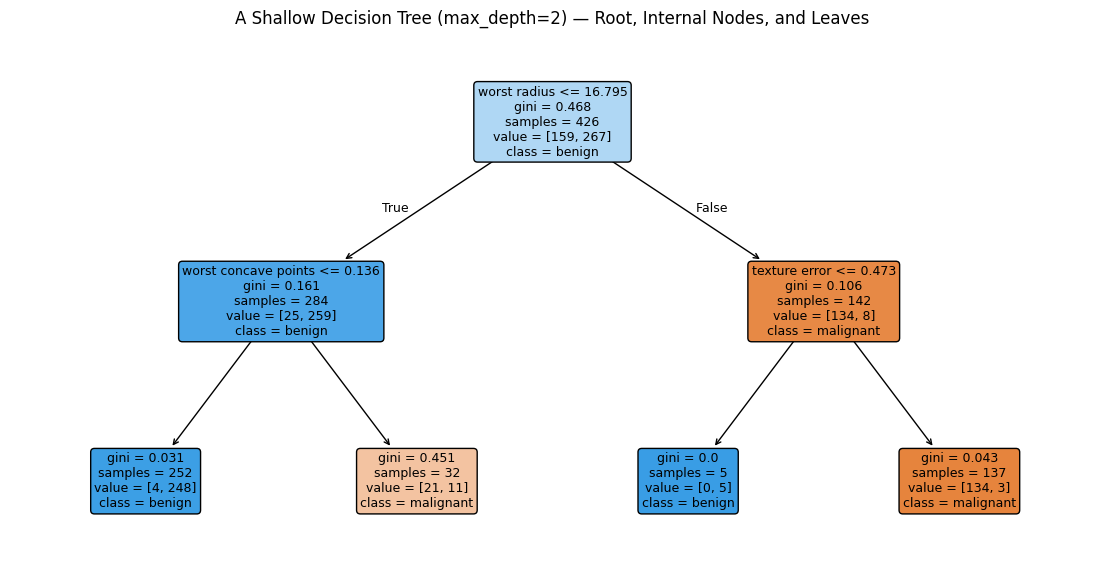

Root node splits on: worst radius
Threshold: 16.795


In [3]:
# Train a small, shallow decision tree and visualize its structure (nodes/splits/leaves)
small_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(small_tree, feature_names=data.feature_names, class_names=data.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("A Shallow Decision Tree (max_depth=2) — Root, Internal Nodes, and Leaves")
plt.show()

print("Root node splits on:", data.feature_names[small_tree.tree_.feature[0]])
print(f"Threshold: {small_tree.tree_.threshold[0]:.3f}")


## 2. Entropy

### What?
**Entropy** measures the **impurity/disorder** of a set of labels. For a binary (or multi-class) split with class proportions $p_i$:

$$H(S) = -\sum_i p_i \log_2 p_i$$

- $H(S) = 0$: perfectly pure (all one class).
- $H(S) = 1$ (for binary classes): maximally impure (50/50 split).

### Why?
Entropy gives us a mathematical way to quantify "how mixed up" a node's labels are — the tree-building algorithm wants to find splits that **reduce** entropy as much as possible.

### How?
Compute entropy before a split, compute the weighted average entropy of the resulting child nodes after the split, and see how much it decreased (this decrease is the **Information Gain**, next section).


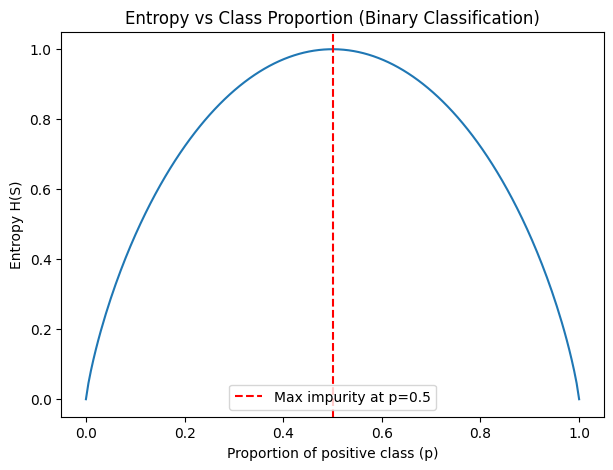

Entropy at p=0.5 (max impurity): 1.0000
Entropy at p=0.9 (mostly pure):  0.4690
Entropy at p=1.0 (perfectly pure): 0.0000


In [4]:
# Compute and visualize entropy for a binary class distribution
def entropy(p):
    # p = proportion of the positive class
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

p_values = np.linspace(0, 1, 200)
entropy_values = [entropy(p) for p in p_values]

plt.figure(figsize=(7, 5))
plt.plot(p_values, entropy_values)
plt.xlabel("Proportion of positive class (p)")
plt.ylabel("Entropy H(S)")
plt.title("Entropy vs Class Proportion (Binary Classification)")
plt.axvline(0.5, color='red', linestyle='--', label='Max impurity at p=0.5')
plt.legend()
plt.show()

print(f"Entropy at p=0.5 (max impurity): {entropy(0.5):.4f}")
print(f"Entropy at p=0.9 (mostly pure):  {entropy(0.9):.4f}")
print(f"Entropy at p=1.0 (perfectly pure): {entropy(1.0):.4f}")


## 3. Information Gain

### What?
**Information Gain (IG)** measures how much entropy is **reduced** by a split:

$$IG(S, A) = H(S) - \sum_{v \in \text{values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

where $S$ is the parent node's data, and $S_v$ are the child nodes after splitting on feature $A$.

### Why?
At each node, the tree-building algorithm evaluates **every possible feature and threshold**, computes the Information Gain for each candidate split, and picks the split with the **highest** IG — greedily maximizing purity improvement at each step.

### How?
Higher IG = better split (bigger reduction in disorder). A feature that perfectly separates the classes gives $IG = H(S)$ (entropy drops to 0 in the children).


In [5]:
# Manually compute Information Gain for a simple split, then verify against a real feature from the dataset
def weighted_entropy(y_left, y_right):
    n = len(y_left) + len(y_right)
    p_left = len(y_left) / n
    p_right = len(y_right) / n
    e_left = entropy(np.mean(y_left)) if len(y_left) > 0 else 0
    e_right = entropy(np.mean(y_right)) if len(y_right) > 0 else 0
    return p_left * e_left + p_right * e_right

def information_gain(y_parent, y_left, y_right):
    parent_entropy = entropy(np.mean(y_parent))
    child_entropy = weighted_entropy(y_left, y_right)
    return parent_entropy - child_entropy

# Use the same feature/threshold the real tree chose at the root
best_feature = data.feature_names[small_tree.tree_.feature[0]]
best_threshold = small_tree.tree_.threshold[0]

mask = X_train[best_feature].values <= best_threshold
y_left = y_train.values[mask]
y_right = y_train.values[~mask]

ig = information_gain(y_train.values, y_left, y_right)
print(f"Splitting on '{best_feature}' <= {best_threshold:.3f}")
print(f"Parent entropy: {entropy(y_train.mean()):.4f}")
print(f"Weighted child entropy: {weighted_entropy(y_left, y_right):.4f}")
print(f"Information Gain: {ig:.4f}")
print("\n--> This is (approximately) the split the real DecisionTreeClassifier chose at the root,")
print("    because it's searching for the split that maximizes Information Gain (or minimizes Gini).")


Splitting on 'worst radius' <= 16.795
Parent entropy: 0.9531
Weighted child entropy: 0.3908
Information Gain: 0.5623

--> This is (approximately) the split the real DecisionTreeClassifier chose at the root,
    because it's searching for the split that maximizes Information Gain (or minimizes Gini).


## 4. Gini Impurity

### What?
An alternative impurity measure to entropy, and scikit-learn's **default** criterion:

$$G = 1 - \sum_i p_i^2$$

### Why?
Gini impurity is **computationally cheaper** than entropy (no logarithms) and in practice produces very similar trees. Both measure the same underlying idea: how "mixed" the classes are in a node.

### How?
- $G = 0$: pure node.
- $G = 0.5$ (binary, 50/50 split): maximum impurity.

### Entropy vs. Gini
| | Entropy | Gini |
|---|---|---|
| Formula | $-\sum p_i \log_2 p_i$ | $1 - \sum p_i^2$ |
| Range (binary) | 0 to 1 | 0 to 0.5 |
| Computation | Slower (log) | Faster |
| Practical difference | Usually negligible; entropy penalizes impurity slightly more at extremes | Default in sklearn's `DecisionTreeClassifier` |


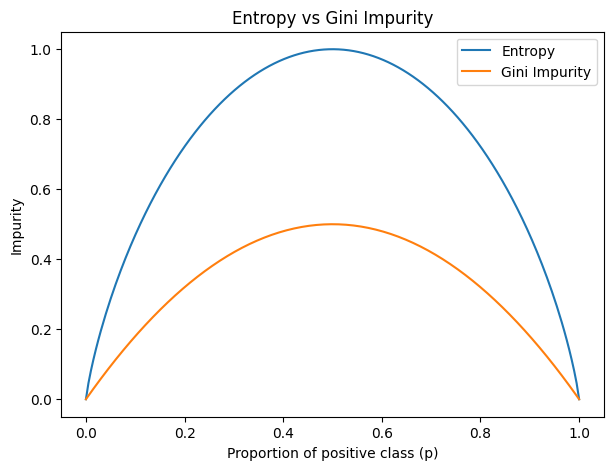

Entropy-based tree test accuracy: 0.951048951048951
Gini-based tree test accuracy:    0.9440559440559441
--> Usually very close, confirming the criteria are largely interchangeable in practice.


In [6]:
# Compare Entropy vs Gini impurity curves side by side
def gini(p):
    return 1 - (p**2 + (1-p)**2)

gini_values = [gini(p) for p in p_values]

plt.figure(figsize=(7, 5))
plt.plot(p_values, entropy_values, label="Entropy")
plt.plot(p_values, gini_values, label="Gini Impurity")
plt.xlabel("Proportion of positive class (p)")
plt.ylabel("Impurity")
plt.title("Entropy vs Gini Impurity")
plt.legend()
plt.show()

# Train trees with each criterion and compare
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42).fit(X_train, y_train)
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42).fit(X_train, y_train)

print("Entropy-based tree test accuracy:", accuracy_score(y_test, tree_entropy.predict(X_test)))
print("Gini-based tree test accuracy:   ", accuracy_score(y_test, tree_gini.predict(X_test)))
print("--> Usually very close, confirming the criteria are largely interchangeable in practice.")


## 5. Tree Depth & Pruning

### What?
- **Tree depth**: the number of splits from root to the deepest leaf. Deeper trees can capture more complex patterns.
- **Pruning**: limiting tree growth (or trimming an already-grown tree) to prevent it from becoming too complex.

### Why?
An **unconstrained decision tree** will keep splitting until every leaf is pure (or has 1 sample) — this almost always **overfits** dramatically (recall Day 4's overfitting discussion), since it memorizes noise in the training data.

### How? — Key hyperparameters
- `max_depth`: caps how deep the tree can grow.
- `min_samples_split`: minimum samples required to split a node further.
- `min_samples_leaf`: minimum samples required in a leaf node.
- `max_leaf_nodes`: caps total number of leaves.
- **Pre-pruning**: stop growth early using the above (most common in practice).
- **Post-pruning**: grow the full tree, then trim back branches that don't improve validation performance (e.g., cost-complexity pruning, `ccp_alpha` in sklearn).


In [7]:
# Demonstrate overfitting with an unconstrained tree vs a depth-limited tree
tree_unlimited = DecisionTreeClassifier(random_state=42)  # no max_depth -> grows until pure
tree_unlimited.fit(X_train, y_train)

tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_limited.fit(X_train, y_train)

print(f"Unconstrained tree — depth: {tree_unlimited.get_depth()}, leaves: {tree_unlimited.get_n_leaves()}")
print(f"  Train accuracy: {accuracy_score(y_train, tree_unlimited.predict(X_train)):.4f}")
print(f"  Test accuracy:  {accuracy_score(y_test, tree_unlimited.predict(X_test)):.4f}")

print(f"\nDepth-limited tree (max_depth=3) — depth: {tree_limited.get_depth()}, leaves: {tree_limited.get_n_leaves()}")
print(f"  Train accuracy: {accuracy_score(y_train, tree_limited.predict(X_train)):.4f}")
print(f"  Test accuracy:  {accuracy_score(y_test, tree_limited.predict(X_test)):.4f}")

print("\n--> The unconstrained tree gets ~100% train accuracy (memorized the data) but doesn't")
print("    necessarily generalize better -- classic overfitting symptom: huge train/test gap risk.")


Unconstrained tree — depth: 7, leaves: 18
  Train accuracy: 1.0000
  Test accuracy:  0.9231

Depth-limited tree (max_depth=3) — depth: 3, leaves: 7
  Train accuracy: 0.9765
  Test accuracy:  0.9441

--> The unconstrained tree gets ~100% train accuracy (memorized the data) but doesn't
    necessarily generalize better -- classic overfitting symptom: huge train/test gap risk.


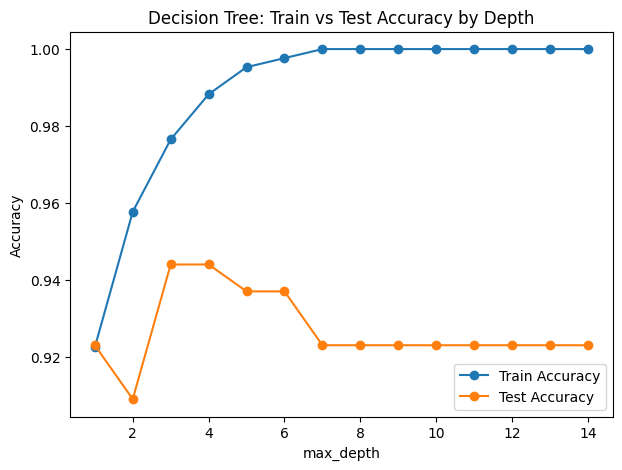

Best max_depth by test accuracy: 3
--> As depth increases, train accuracy keeps climbing toward 100%, but test accuracy
    plateaus/declines once the tree starts overfitting -- exactly like Day 4's polynomial degree demo.


In [8]:
# Visualize how max_depth affects train vs test accuracy (bias-variance trade-off for trees)
depths = range(1, 15)
train_accs, test_accs = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test, t.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(list(depths), train_accs, marker='o', label="Train Accuracy")
plt.plot(list(depths), test_accs, marker='o', label="Test Accuracy")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Test Accuracy by Depth")
plt.legend()
plt.show()

best_depth = list(depths)[np.argmax(test_accs)]
print(f"Best max_depth by test accuracy: {best_depth}")
print("--> As depth increases, train accuracy keeps climbing toward 100%, but test accuracy")
print("    plateaus/declines once the tree starts overfitting -- exactly like Day 4's polynomial degree demo.")


## 6. Random Forest: Bagging, Bootstrap Sampling, Random Feature Selection, Voting/Averaging

### What?
A **Random Forest** is an **ensemble** of many decision trees, where randomness is deliberately injected in two places to make the trees diverse:
1. **Bootstrap sampling (Bagging)**: each tree is trained on a random sample drawn **with replacement** from the training data (same size as original, but ~63% unique samples per tree).
2. **Random feature selection**: at each split, only a random subset of features is considered (not all of them) — this decorrelates the trees further.

Final prediction:
- **Classification**: majority **vote** across all trees.
- **Regression**: **average** of all trees' predictions.

### Why?
A single deep decision tree has **high variance** — small changes in training data can produce a completely different tree. Random Forest reduces variance by **averaging many diverse, high-variance trees**, without significantly increasing bias — a direct application of the bias-variance trade-off (Day 5).

### How? — Why does averaging reduce variance?
If individual trees' errors are **not perfectly correlated** (which the two randomness sources ensure), then averaging cancels out much of their individual noise, similar to how averaging many noisy measurements gives a more stable estimate.

### Key hyperparameters
- `n_estimators`: number of trees in the forest — more trees generally = more stable (with diminishing returns), rarely causes overfitting by itself.
- `max_depth` / `min_samples_leaf`: still control individual tree complexity.
- `max_features`: number of features considered at each split (the "random feature selection" knob).


In [9]:
# Illustrate bootstrap sampling: draw several bootstrap samples and see the overlap/diversity
np.random.seed(7)
original_indices = np.arange(10)  # toy dataset of 10 samples

for i in range(3):
    bootstrap_sample = np.random.choice(original_indices, size=10, replace=True)
    unique_count = len(np.unique(bootstrap_sample))
    print(f"Bootstrap sample {i+1}: {sorted(bootstrap_sample)}  (unique original samples used: {unique_count}/10)")

print("\n--> On average, a bootstrap sample contains about 63.2% of the unique original samples")
print("    (the rest are duplicates); the remaining ~36.8% are called 'out-of-bag' (OOB) samples,")
print("    which can be used for a free internal validation estimate without a separate test set.")


Bootstrap sample 1: [np.int64(3), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(9), np.int64(9)]  (unique original samples used: 6/10)
Bootstrap sample 2: [np.int64(0), np.int64(0), np.int64(4), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(9)]  (unique original samples used: 6/10)
Bootstrap sample 3: [np.int64(0), np.int64(0), np.int64(2), np.int64(3), np.int64(5), np.int64(5), np.int64(7), np.int64(8), np.int64(8), np.int64(8)]  (unique original samples used: 6/10)

--> On average, a bootstrap sample contains about 63.2% of the unique original samples
    (the rest are duplicates); the remaining ~36.8% are called 'out-of-bag' (OOB) samples,
    which can be used for a free internal validation estimate without a separate test set.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: U

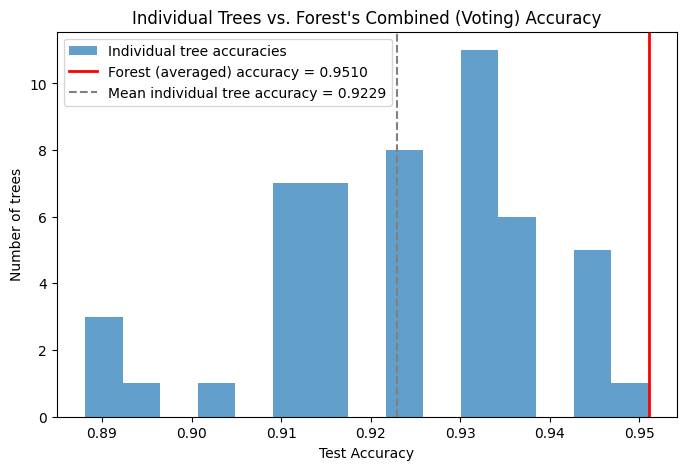

--> The forest's voted prediction typically matches or beats the AVERAGE individual tree,
    and is much more stable than relying on any single tree.


In [10]:
# Visualize variance reduction: predictions of individual trees vs the forest's averaged prediction
n_trees_demo = 50
individual_tree_accs = []

rf_demo = RandomForestClassifier(n_estimators=n_trees_demo, max_depth=3, random_state=42, bootstrap=True)
rf_demo.fit(X_train, y_train)

for tree in rf_demo.estimators_:
    individual_tree_accs.append(accuracy_score(y_test, tree.predict(X_test)))

forest_acc = accuracy_score(y_test, rf_demo.predict(X_test))

plt.figure(figsize=(8, 5))
plt.hist(individual_tree_accs, bins=15, alpha=0.7, label="Individual tree accuracies")
plt.axvline(forest_acc, color='red', linewidth=2, label=f"Forest (averaged) accuracy = {forest_acc:.4f}")
plt.axvline(np.mean(individual_tree_accs), color='gray', linestyle='--',
            label=f"Mean individual tree accuracy = {np.mean(individual_tree_accs):.4f}")
plt.xlabel("Test Accuracy"); plt.ylabel("Number of trees")
plt.title("Individual Trees vs. Forest's Combined (Voting) Accuracy")
plt.legend()
plt.show()

print("--> The forest's voted prediction typically matches or beats the AVERAGE individual tree,")
print("    and is much more stable than relying on any single tree.")


## 7. Coding Practice — Decision Tree vs Random Forest, Tuning `max_depth` and `n_estimators`


In [11]:
# Baseline comparison: single Decision Tree vs Random Forest (default-ish settings)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

for name, model in [("Decision Tree", dt_model), ("Random Forest", rf_model)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: Train Acc = {train_acc:.4f} | Test Acc = {test_acc:.4f} | Gap = {train_acc - test_acc:.4f}")

print("\n--> Random Forest typically shows a SMALLER train-test gap than a single tree of the same")
print("    depth, directly demonstrating its variance-reduction effect.")


Decision Tree: Train Acc = 0.9953 | Test Acc = 0.9371 | Gap = 0.0582
Random Forest: Train Acc = 0.9930 | Test Acc = 0.9510 | Gap = 0.0419

--> Random Forest typically shows a SMALLER train-test gap than a single tree of the same
    depth, directly demonstrating its variance-reduction effect.


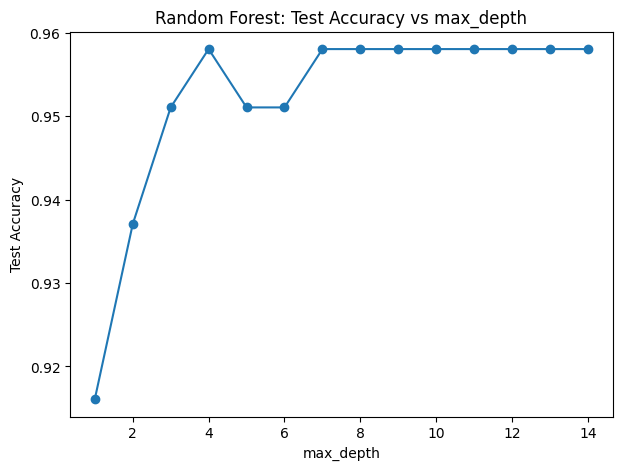

Best max_depth for Random Forest: 4, accuracy: 0.9580


In [12]:
# Tune max_depth for Random Forest
depths_rf = range(1, 15)
rf_test_accs = []

for d in depths_rf:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42).fit(X_train, y_train)
    rf_test_accs.append(accuracy_score(y_test, rf_d.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(list(depths_rf), rf_test_accs, marker='o')
plt.xlabel("max_depth"); plt.ylabel("Test Accuracy")
plt.title("Random Forest: Test Accuracy vs max_depth")
plt.show()

best_depth_rf = list(depths_rf)[np.argmax(rf_test_accs)]
print(f"Best max_depth for Random Forest: {best_depth_rf}, accuracy: {max(rf_test_accs):.4f}")


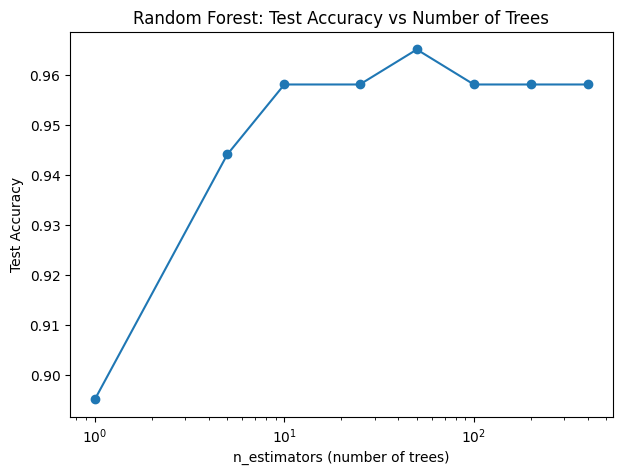

Accuracy by n_estimators:
  n_estimators=1: accuracy=0.8951
  n_estimators=5: accuracy=0.9441
  n_estimators=10: accuracy=0.9580
  n_estimators=25: accuracy=0.9580
  n_estimators=50: accuracy=0.9650
  n_estimators=100: accuracy=0.9580
  n_estimators=200: accuracy=0.9580
  n_estimators=400: accuracy=0.9580

--> Accuracy improves quickly then plateaus -- more trees rarely hurt (unlike deeper single
    trees), but returns diminish and computation cost keeps growing linearly.


In [13]:
# Tune n_estimators (number of trees)
n_estimators_range = [1, 5, 10, 25, 50, 100, 200, 400]
n_est_test_accs = []

for n in n_estimators_range:
    rf_n = RandomForestClassifier(n_estimators=n, max_depth=best_depth_rf, random_state=42).fit(X_train, y_train)
    n_est_test_accs.append(accuracy_score(y_test, rf_n.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(n_estimators_range, n_est_test_accs, marker='o')
plt.xlabel("n_estimators (number of trees)"); plt.ylabel("Test Accuracy")
plt.title("Random Forest: Test Accuracy vs Number of Trees")
plt.xscale('log')
plt.show()

print("Accuracy by n_estimators:")
for n, acc in zip(n_estimators_range, n_est_test_accs):
    print(f"  n_estimators={n}: accuracy={acc:.4f}")
print("\n--> Accuracy improves quickly then plateaus -- more trees rarely hurt (unlike deeper single")
print("    trees), but returns diminish and computation cost keeps growing linearly.")


In [14]:
# Combine into a small GridSearchCV to find the jointly-best combination
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
final_test_acc = accuracy_score(y_test, best_rf.predict(X_test))
print("Final test accuracy with tuned Random Forest:", round(final_test_acc, 4))


Best parameters found: {'max_depth': 7, 'n_estimators': 100}
Best cross-validation accuracy: 0.9624
Final test accuracy with tuned Random Forest: 0.958


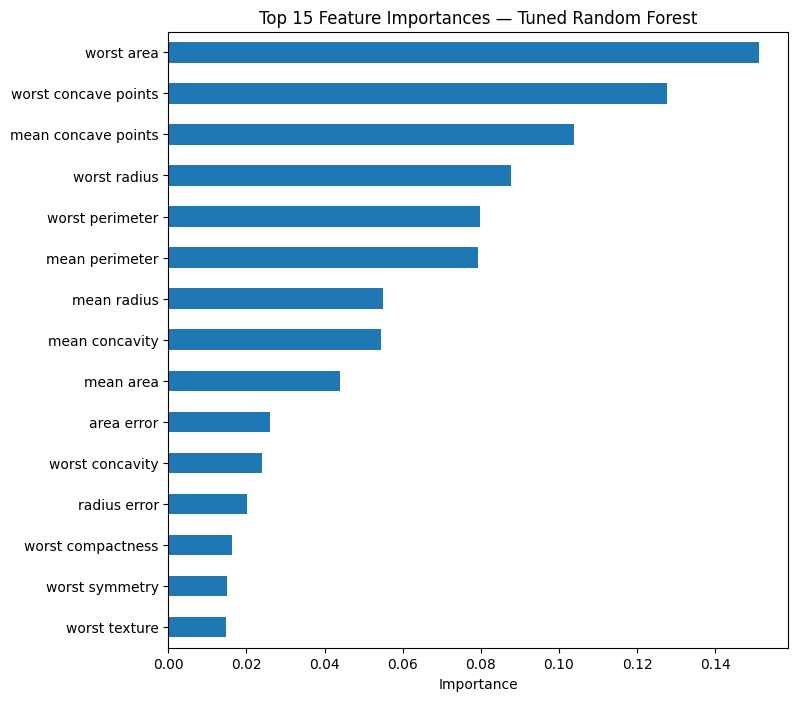

Top 5 most important features:
worst area              0.1512
worst concave points    0.1276
mean concave points     0.1039
worst radius            0.0877
worst perimeter         0.0797
dtype: float64


In [15]:
# Feature importance from the tuned Random Forest -- a valuable interpretability bonus
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.show()

print("Top 5 most important features:")
print(importances.head(5))


              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



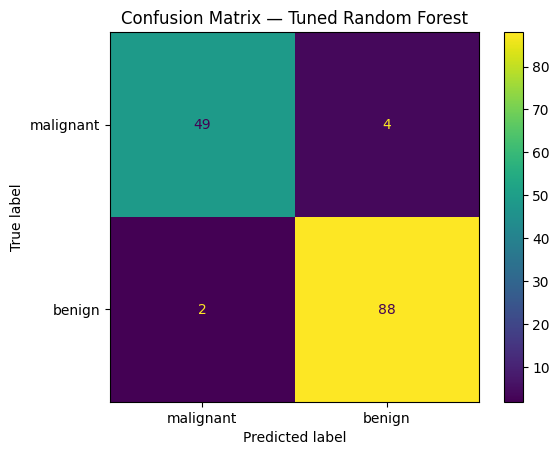

In [16]:
# Final classification report for the tuned Random Forest
print(classification_report(y_test, best_rf.predict(X_test), target_names=data.target_names))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=data.target_names)
plt.title("Confusion Matrix — Tuned Random Forest")
plt.show()


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Entropy / Gini | Day 3's probability concepts (measuring "surprise"/disorder) |
| No scaling needed | Day 4's discussion on why tree-based models are scale-invariant |
| Overfitting with unlimited depth | Day 4/5's bias-variance and overfitting visualizations |
| Random Forest variance reduction | Day 5's bias-variance trade-off, applied via ensembling instead of regularization |
| GridSearchCV tuning | Preview of Day 14's Hyperparameter Optimization |


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why can Random Forest reduce overfitting compared with a single deep tree?**
   *Hint: bagging + random feature selection decorrelate individual trees; averaging many high-variance, low-correlation trees reduces overall variance without much increase in bias.*

2. **What's the difference between entropy and Gini impurity? Does it matter much in practice?**
   *Hint: similar shape, entropy involves logs, Gini is the sklearn default; usually produces similar trees.*

3. **How does a decision tree decide where to split?**
   *Hint: greedily searches over features/thresholds, picks the split maximizing Information Gain (or minimizing Gini impurity) at each node.*

4. **What are the main hyperparameters for controlling decision tree complexity?**
   *Hint: max_depth, min_samples_split, min_samples_leaf, max_leaf_nodes.*

5. **What is bootstrap sampling, and why does Random Forest use it?**
   *Hint: sampling with replacement to create diverse training sets per tree; introduces randomness needed for variance reduction via averaging.*

6. **Why does increasing `n_estimators` rarely cause Random Forest to overfit, unlike increasing tree depth?**
   *Hint: more trees just averages more (already regularized via bagging/feature randomness) estimates together — it stabilizes rather than adds model complexity/capacity in the way depth does.*

7. **(Bonus) What are out-of-bag (OOB) samples, and how can they be used?**
   *Hint: ~36.8% of data not included in a given tree's bootstrap sample; can serve as a free validation set for that tree (`oob_score=True` in sklearn).*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain the parts of a decision tree: root, internal nodes, leaves, splits.
- [ ] Write the entropy and Gini impurity formulas from memory and explain what each measures.
- [ ] Explain Information Gain and how it's used to choose the best split.
- [ ] Explain why unconstrained decision trees overfit, and list hyperparameters that control this.
- [ ] Explain bagging, bootstrap sampling, and random feature selection in Random Forest.
- [ ] Explain, in your own words, why averaging many decorrelated trees reduces variance.
- [ ] Tune `max_depth` and `n_estimators` for a Random Forest and interpret the resulting accuracy curves.
- [ ] Extract and interpret feature importances from a trained Random Forest.

### 📌 Daily Output (per the planner)
Decision Tree and Random Forest trained on the Breast Cancer dataset, with `max_depth` and `n_estimators` tuned (individually and via `GridSearchCV`), train/test accuracy gap compared between the single tree and the forest, feature importances extracted, and a final classification report + confusion matrix produced (Sections 7 above).

Close this notebook and re-explain, from memory, why the train-test accuracy gap differs between the single Decision Tree and the Random Forest — that's the real test of Day 7 mastery.
